### Problem Statement : Perform sentiment analysis with a recurrent neural networks RNN

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, TextVectorization, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")





TensorFlow Version: 2.19.0


In [2]:
# ==========================================
# Step 1: Data Preparation
# ==========================================
print("\n--- Step 1: Loading Dataset ---")
# Replace this URL with your local file path if you downloaded the CSV
url = "https://raw.githubusercontent.com/skillcate/sentiment-analysis-with-deep-neural-networks/main/a1_IMDB_Dataset.csv"

try:
    df = pd.read_csv(url)
    print(f"Dataset loaded successfully! Shape: {df.shape}")
except Exception as e:
    print(f"Error loading CSV from URL. Please download it locally and change the path. Error: {e}")
    # Fallback to Keras inbuilt IMDB if URL fails for any reason
    print("Falling back to a small subset just to keep the code running...")
    df = pd.DataFrame({'review': ['good movie', 'bad movie'], 'sentiment': ['positive', 'negative']})

# Map string labels to binary integers (positive -> 1, negative -> 0)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split dataset into training (80%) and test sets (20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)



--- Step 1: Loading Dataset ---
Dataset loaded successfully! Shape: (50000, 2)


In [3]:
# ==========================================
# Step 2 & 3: Sequence Generation & Embedding Setup
# ==========================================
print("\n--- Step 2 & 3: Creating Sequences and Embeddings ---")
# To save laptop memory, we limit vocabulary to top 10,000 words and sequence length to 150 words.
VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 150

# TextVectorization turns raw strings into sequences of integers
vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    output_mode='int'
)

# Learn the vocabulary from the training data
print("Building vocabulary (this might take a few seconds)...")
vectorizer.adapt(X_train.to_numpy())



--- Step 2 & 3: Creating Sequences and Embeddings ---
Building vocabulary (this might take a few seconds)...


In [4]:
# ==========================================
# Step 5: RNN Model Architecture
# ==========================================
print("\n--- Step 5: Defining RNN (LSTM) Architecture ---")
# Using LSTM (Long Short-Term Memory) as it handles text sequences well
model = Sequential([
    # 1. Input layer for raw strings
    tf.keras.Input(shape=(1,), dtype=tf.string),
    
    # 2. Vectorize the strings to integers
    vectorizer,
    
    # 3. Embedding Layer: Converts integers to fixed-size dense vectors (size 32 to save memory)
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, mask_zero=True),
    
    # 4. LSTM Layer: The core Recurrent Neural Network layer (32 units to be light on GPU/CPU)
    LSTM(32, return_sequences=False),
    
    # Dropout to prevent overfitting
    Dropout(0.5),
    
    # 5. Output Layer: 1 neuron with sigmoid for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

model.summary()



--- Step 5: Defining RNN (LSTM) Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, 150)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 150, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:

# ==========================================
# Step 6: Training
# ==========================================
print("\n--- Step 6: Compiling and Training ---")
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Hardware consideration: 10 epochs, moderate batch size. 
EPOCHS = 10
BATCH_SIZE = 64

# Training the model. We use validation_split to monitor performance on unseen data.
history = model.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2, # 20% of training data used for validation
    verbose=1
)



--- Step 6: Compiling and Training ---
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.6611 - loss: 0.5753 - val_accuracy: 0.8424 - val_loss: 0.3589
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.8834 - loss: 0.3041 - val_accuracy: 0.8478 - val_loss: 0.3595
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.9110 - loss: 0.2422 - val_accuracy: 0.8520 - val_loss: 0.3472
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.9225 - loss: 0.2141 - val_accuracy: 0.8410 - val_loss: 0.3950
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9356 - loss: 0.1744 - val_accuracy: 0.8450 - val_loss: 0.4159
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9452 - loss: 0.1496 - val_accuracy: 0.8441 - val_loss: 0.4210
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9523 - loss: 0.1321 - val_accuracy: 0.8409 - val_loss: 0.5379
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/s

In [6]:
# ==========================================
# Step 7: Evaluation
# ==========================================
print("\n--- Step 7: Evaluating on Test Set ---")
test_loss, test_acc = model.evaluate(X_test.to_numpy(), y_test.to_numpy())
print(f"Final Test Accuracy: {test_acc*100:.2f}%")




--- Step 7: Evaluating on Test Set ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8353 - loss: 0.4843
Final Test Accuracy: 83.73%


In [9]:
# ==========================================
# Step 8 & 9: Inference & Post-Processing
# ==========================================
print("\n--- Step 8 & 9: Inference (Testing custom reviews) ---")
custom_reviews = [
    "This movie was absolutely fantastic, I loved the acting!",
    "Terrible plot, awful characters, a complete waste of time."
]

# THE FIX: Convert the list to a TensorFlow constant (tensor) of strings
custom_reviews_tensor = tf.constant(custom_reviews)

# Now pass the tensor into the predict function
predictions = model.predict(custom_reviews_tensor)

for review, pred in zip(custom_reviews, predictions):
    sentiment = "Positive" if pred[0] > 0.5 else "Negative"
    print(f"\nReview: '{review}'\nPredicted Sentiment: {sentiment} (Score: {pred[0]:.4f})")




--- Step 8 & 9: Inference (Testing custom reviews) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step

Review: 'This movie was absolutely fantastic, I loved the acting!'
Predicted Sentiment: Positive (Score: 0.9531)

Review: 'Terrible plot, awful characters, a complete waste of time.'
Predicted Sentiment: Negative (Score: 0.0004)



--- Step 10: Visualizing Training Performance ---


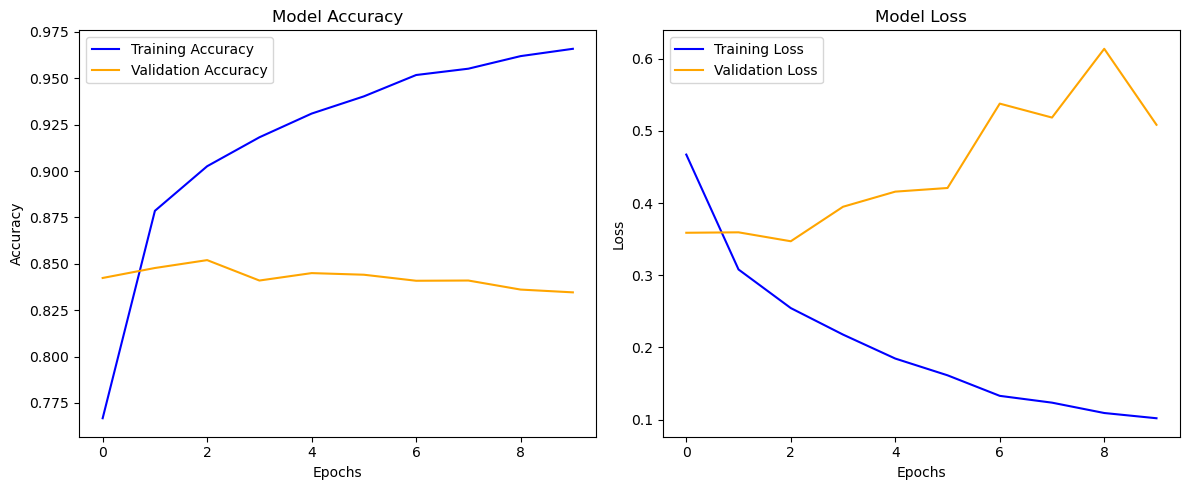

In [10]:
# ==========================================
# Step 10: Visualization
# ==========================================
print("\n--- Step 10: Visualizing Training Performance ---")
# Plotting accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()